# 05 - Multi-Factor Composition Grid

Systematically test 8 multi-factor composition strategies at the
stock-selection level across all 11 industries.  Each variant
produces per-industry monthly returns that feed into NB06 portfolio
construction.

**Variants tested:**

| # | Label | Description |
|---|-------|-------------|
| 1 | SF (best-1) | Single factor, rolling IC selection |
| 2 | All6-EW | All 6 factors, equal weight |
| 3 | All6-ICwt | All 6 factors, IC-proportional weight |
| 4 | Top3-EW | Top 3 by abs(IC), no correlation filter, EW |
| 5 | Top3-ICwt | Top 3 by abs(IC), no correlation filter, IC-wt |
| 6 | Corr03-EW | IC-correlation filter rho<0.3, EW |
| 7 | Corr03-ICwt | IC-correlation filter rho<0.3, IC-wt |
| 8 | Corr05-EW | IC-correlation filter rho<0.5, EW |

In [1]:
import sys
sys.path.insert(0, '..')

import os
import time
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

from src.data_loader import (
    load_signal_data, load_benchmark, FACTOR_COLUMNS, FACTOR_NAMES,
    INDUSTRIES, SMALL_INDUSTRIES, RETURN_COL_TESTING, RETURN_COL_PORTFOLIO,
)
from src.neutralization import neutralize_cross_section, impute_median
from src.industry_portfolio import backtest_composite_factor
from src.performance import (
    performance_table, is_vs_oos_table, plot_cumulative_returns, plot_drawdown,
)

DATA_DIR = '../data'
OUTPUT_DIR = '../output'
OOS_START = '2014-01-01'

os.makedirs(f'{OUTPUT_DIR}/csv', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/figures', exist_ok=True)

## 1. Data Preparation

In [2]:
df = load_signal_data(DATA_DIR)
benchmark = load_benchmark(DATA_DIR)

df_valid = df.dropna(subset=['industry']).copy()
df_neutral = neutralize_cross_section(df_valid, FACTOR_COLUMNS)
neutral_factors = [f'{f}_neutral' for f in FACTOR_COLUMNS]
for c in neutral_factors:
    df_neutral[c] = impute_median(df_neutral, c)

print(f'Panel: {df_neutral.shape[0]} rows, {df_neutral["ym"].nunique()} months')
print(f'Factors: {neutral_factors}')

  Dropped 12 duplicate (ric, ym) rows
Signal data loaded: 98,742 rows x 51 cols | 2004-01 to 2025-03
Benchmark loaded: 289 months | 2001-05 to 2025-05


Panel: 98616 rows, 255 months
Factors: ['log_mktcap_neutral', 'pb_w_neutral', 'roe_w_neutral', 'mom_11m_w_neutral', 'ret_vol_w_neutral', 'div_yield_w_neutral']


## 2. Run All 8 Multi-Factor Variants

Each variant calls `backtest_composite_factor` with different
parameters for `corr_threshold`, `min_ic`, `max_factors`, and `weighting`.

In [3]:
VARIANTS = {
    'All6-EW':       dict(corr_threshold=2.0, min_ic=0.0, max_factors=None, weighting='equal'),
    'All6-ICwt':     dict(corr_threshold=2.0, min_ic=0.0, max_factors=None, weighting='ic_proportional'),
    'Top3-EW':       dict(corr_threshold=2.0, min_ic=0.001, max_factors=3, weighting='equal'),
    'Top3-ICwt':     dict(corr_threshold=2.0, min_ic=0.001, max_factors=3, weighting='ic_proportional'),
    'Corr03-EW':     dict(corr_threshold=0.3, min_ic=0.01, max_factors=None, weighting='equal'),
    'Corr03-ICwt':   dict(corr_threshold=0.3, min_ic=0.01, max_factors=None, weighting='ic_proportional'),
    'Corr05-EW':     dict(corr_threshold=0.5, min_ic=0.01, max_factors=None, weighting='equal'),
}

variant_results = {}  # label -> {wide: DataFrame, details: dict}

for label, params in VARIANTS.items():
    t0 = time.time()
    print(f'\n=== {label} ===')
    details = {}
    wide = None
    for ind in INDUSTRIES:
        ind_df = df_neutral[df_neutral['industry'] == ind]
        res = backtest_composite_factor(
            ind_df, industry=ind, factors=neutral_factors,
            window=60,
            corr_threshold=params['corr_threshold'],
            weighting=params['weighting'],
            min_ic=params['min_ic'],
            max_factors=params.get('max_factors'),
            return_col_testing=RETURN_COL_TESTING,
            return_col_portfolio=RETURN_COL_PORTFOLIO,
        )
        details[ind] = res
        temp = res[['ym', 'return']].rename(columns={'return': ind})
        if wide is None:
            wide = temp
        else:
            wide = wide.merge(temp, on='ym', how='outer')
    wide = wide.sort_values('ym').set_index('ym')
    wide.index = pd.to_datetime(wide.index)
    variant_results[label] = {'wide': wide, 'details': details}
    print(f'  Done in {time.time()-t0:.1f}s, {wide.shape[0]} months')

# Also load single-factor for comparison
sf_wide = pd.read_csv(f'{OUTPUT_DIR}/csv/single_factor_raw_industry_returns.csv',
                       index_col=0, parse_dates=True)
print(f'\nAll variants computed. SF loaded: {sf_wide.shape}')


=== All6-EW ===


  Done in 42.3s, 194 months

=== All6-ICwt ===


  Done in 41.8s, 194 months

=== Top3-EW ===


  Done in 25.9s, 194 months

=== Top3-ICwt ===


  Done in 25.8s, 194 months

=== Corr03-EW ===


  Done in 29.3s, 194 months

=== Corr03-ICwt ===


  Done in 29.2s, 194 months

=== Corr05-EW ===


  Done in 31.5s, 194 months

All variants computed. SF loaded: (194, 11)


## 3. Full-Period Performance Comparison

In [4]:
# Build master returns for each variant
sf_master = sf_wide[INDUSTRIES].mean(axis=1)
masters = {'SF (best-1)': sf_master}
for label in VARIANTS:
    masters[label] = variant_results[label]['wide'][INDUSTRIES].mean(axis=1)

common = sf_master.dropna().index.intersection(benchmark.dropna().index)
for label in masters:
    common = common.intersection(masters[label].dropna().index)

perf_dict = {'MSCI EM': benchmark.loc[common]}
for label, m in masters.items():
    perf_dict[label] = m.loc[common]

perf = performance_table(perf_dict, benchmark=benchmark)
print('=== Full-Period Performance ===')
print(perf[['Ann. Mean', 'Ann. Std', 'Sharpe', 'IR', 'Max DD', 'Total Return']].round(4).to_string())

=== Full-Period Performance ===
             Ann. Mean  Ann. Std  Sharpe      IR  Max DD  Total Return
Strategy                                                              
MSCI EM         0.0635    0.1859  0.3416     NaN  0.3851        1.1164
SF (best-1)     0.1090    0.1834  0.5940  0.8348  0.3106        3.4358
All6-EW         0.1121    0.1770  0.6332  0.9666  0.2861        3.7459
All6-ICwt       0.1103    0.1791  0.6156  0.9384  0.2864        3.5811
Top3-EW         0.1070    0.1783  0.6000  0.8787  0.3024        3.3550
Top3-ICwt       0.1063    0.1784  0.5957  0.8779  0.2823        3.3062
Corr03-EW       0.1067    0.1781  0.5990  0.8907  0.3057        3.3415
Corr03-ICwt     0.1072    0.1789  0.5989  0.8685  0.2946        3.3638
Corr05-EW       0.1043    0.1798  0.5801  0.8200  0.3578        3.1572


## 4. In-Sample vs Out-of-Sample

In [5]:
is_oos = is_vs_oos_table(perf_dict, OOS_START)
print(f'=== IS vs OOS (split: {OOS_START}) ===')
cols = [c for c in is_oos.columns if 'Sharpe' in c or 'Ann. Mean' in c]
print(is_oos[cols].round(4).to_string())

# Concise OOS ranking
oos_sharpe = {}
for label in perf_dict:
    s = perf_dict[label]
    oos = s[s.index >= OOS_START]
    if oos.std() > 0:
        oos_sharpe[label] = oos.mean()*12 / (oos.std()*np.sqrt(12))

print('\n=== OOS Sharpe Ranking ===')
for label, sr in sorted(oos_sharpe.items(), key=lambda x: -x[1]):
    print(f'  {label:20s}  {sr:.4f}')

=== IS vs OOS (split: 2014-01-01) ===
             IS Ann. Mean  IS Sharpe  OOS Ann. Mean  OOS Sharpe
Strategy                                                       
MSCI EM            0.1549     0.6894         0.0236      0.1422
SF (best-1)        0.1996     0.9304         0.0693      0.4136
All6-EW            0.2067     0.9789         0.0707      0.4441
All6-ICwt          0.2059     0.9503         0.0684      0.4294
Top3-EW            0.2113     0.9974         0.0614      0.3824
Top3-ICwt          0.2086     0.9895         0.0616      0.3815
Corr03-EW          0.2166     1.0130         0.0586      0.3691
Corr03-ICwt        0.2038     0.9553         0.0649      0.4033
Corr05-EW          0.2099     0.9913         0.0582      0.3568

=== OOS Sharpe Ranking ===
  All6-EW               0.4441
  All6-ICwt             0.4294
  SF (best-1)           0.4136
  Corr03-ICwt           0.4033
  Top3-EW               0.3824
  Top3-ICwt             0.3815
  Corr03-EW             0.3691
  Corr05-EW  

## 5. Turnover Comparison

In [6]:
print('=== Average Monthly Turnover ===')
print(f'{"Variant":20s}  {"Avg":>8s}  {"Annual":>8s}')
print('-' * 40)

# SF turnover from NB04 data
from src.industry_portfolio import backtest_single_factor
sf_to = []
for ind in INDUSTRIES:
    res = backtest_single_factor(
        df_neutral[df_neutral['industry']==ind], industry=ind,
        factors=neutral_factors, window=60,
        return_col_testing=RETURN_COL_TESTING,
        return_col_portfolio=RETURN_COL_PORTFOLIO,
    )
    sf_to.append(res['turnover'].mean())
sf_avg_to = np.mean(sf_to)
print(f'{"SF (best-1)":20s}  {sf_avg_to:8.3f}  {sf_avg_to*12:7.1f}x')

variant_turnovers = {'SF (best-1)': sf_avg_to}
for label in VARIANTS:
    tos = []
    for ind in INDUSTRIES:
        tos.append(variant_results[label]['details'][ind]['turnover'].mean())
    avg = np.mean(tos)
    variant_turnovers[label] = avg
    print(f'{label:20s}  {avg:8.3f}  {avg*12:7.1f}x')

=== Average Monthly Turnover ===
Variant                    Avg    Annual
----------------------------------------


SF (best-1)              0.121      1.4x
All6-EW                  0.185      2.2x
All6-ICwt                0.142      1.7x
Top3-EW                  0.182      2.2x
Top3-ICwt                0.157      1.9x
Corr03-EW                0.199      2.4x
Corr03-ICwt              0.171      2.1x
Corr05-EW                0.198      2.4x


## 5b. Transaction-Cost-Adjusted Comparison

Different multi-factor variants produce different turnover rates, so their
net-of-TC performance ranking may differ from gross. We compute TC-adjusted
Sharpe ratios at 10, 20, 30, and 50 bps round-trip.

In [7]:
TC_LEVELS = [10, 20, 30, 50]
all_labels = ['SF (best-1)'] + list(VARIANTS.keys())

tc_sharpe = pd.DataFrame(index=all_labels, columns=['Gross'] + [f'{c}bps' for c in TC_LEVELS])
tc_ir     = pd.DataFrame(index=all_labels, columns=['Gross'] + [f'{c}bps' for c in TC_LEVELS])

bm = perf_dict['MSCI EM']

for label in all_labels:
    gross = perf_dict[label]
    to = variant_turnovers[label]
    gross_ann = gross.mean() * 12
    gross_std = gross.std() * np.sqrt(12)
    tc_sharpe.loc[label, 'Gross'] = gross_ann / gross_std if gross_std > 0 else np.nan

    excess = gross - bm
    tc_ir.loc[label, 'Gross'] = (excess.mean() * 12) / (excess.std() * np.sqrt(12)) if excess.std() > 0 else np.nan

    for c in TC_LEVELS:
        cost = to * (c / 10_000)
        net = gross - cost
        net_ann = net.mean() * 12
        net_std = net.std() * np.sqrt(12)
        tc_sharpe.loc[label, f'{c}bps'] = net_ann / net_std if net_std > 0 else np.nan

        net_excess = net - bm
        tc_ir.loc[label, f'{c}bps'] = (net_excess.mean() * 12) / (net_excess.std() * np.sqrt(12)) if net_excess.std() > 0 else np.nan

tc_sharpe = tc_sharpe.astype(float).round(4)
tc_ir     = tc_ir.astype(float).round(4)

print('=== TC-Adjusted Sharpe Ratios ===')
print(tc_sharpe.to_string())
print()
print('=== TC-Adjusted Information Ratios ===')
print(tc_ir.to_string())
print()

best_gross = tc_sharpe['Gross'].idxmax()
best_20    = tc_sharpe['20bps'].idxmax()
best_50    = tc_sharpe['50bps'].idxmax()
print(f'Best by Gross Sharpe:  {best_gross} ({tc_sharpe.loc[best_gross, "Gross"]:.4f})')
print(f'Best by Net-20 Sharpe: {best_20} ({tc_sharpe.loc[best_20, "20bps"]:.4f})')
print(f'Best by Net-50 Sharpe: {best_50} ({tc_sharpe.loc[best_50, "50bps"]:.4f})')

=== TC-Adjusted Sharpe Ratios ===
              Gross   10bps   20bps   30bps   50bps
SF (best-1)  0.5940  0.5861  0.5782  0.5703  0.5546
All6-EW      0.6332  0.6206  0.6080  0.5955  0.5703
All6-ICwt    0.6156  0.6061  0.5966  0.5871  0.5681
Top3-EW      0.6000  0.5878  0.5756  0.5634  0.5389
Top3-ICwt    0.5957  0.5852  0.5746  0.5641  0.5430
Corr03-EW    0.5990  0.5856  0.5722  0.5588  0.5319
Corr03-ICwt  0.5989  0.5875  0.5760  0.5646  0.5416
Corr05-EW    0.5801  0.5669  0.5537  0.5404  0.5140

=== TC-Adjusted Information Ratios ===
              Gross   10bps   20bps   30bps   50bps
SF (best-1)  0.8348  0.8082  0.7816  0.7550  0.7019
All6-EW      0.9666  0.9223  0.8780  0.8337  0.7451
All6-ICwt    0.9384  0.9042  0.8701  0.8359  0.7676
Top3-EW      0.8787  0.8346  0.7906  0.7465  0.6584
Top3-ICwt    0.8779  0.8393  0.8006  0.7620  0.6847
Corr03-EW    0.8907  0.8413  0.7920  0.7427  0.6440
Corr03-ICwt  0.8685  0.8277  0.7869  0.7461  0.6644
Corr05-EW    0.8200  0.7722  0.7243  0.676

/var/folders/t2/j3pgm4697jzddg3qyz5lrvmw0000gn/T/ipykernel_22147/3230734360.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=8)


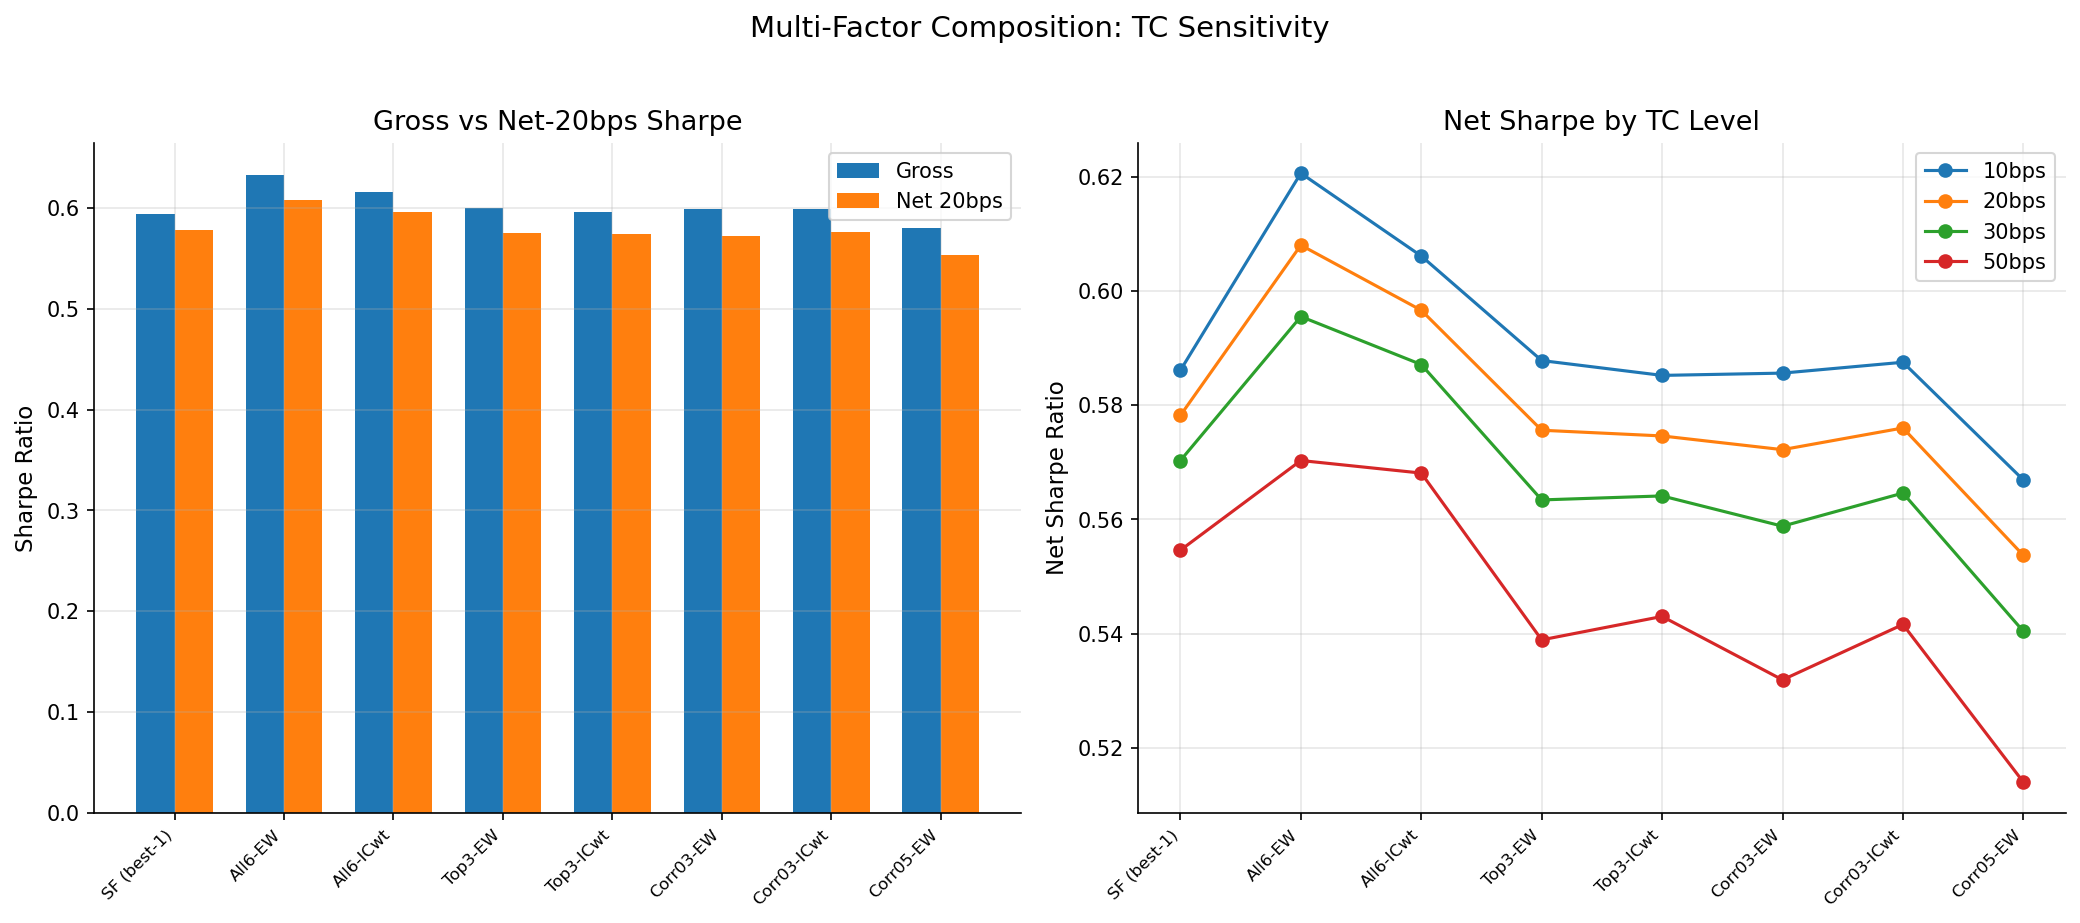

Saved TC analysis to exp3b_tc_sharpe.csv, exp3b_tc_ir.csv, exp3b_tc_sensitivity.pdf


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(all_labels))
width = 0.35
bars1 = axes[0].bar(x - width/2, tc_sharpe['Gross'].values, width, label='Gross')
bars2 = axes[0].bar(x + width/2, tc_sharpe['20bps'].values, width, label='Net 20bps')
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Sharpe Ratio')
axes[0].set_title('Gross vs Net-20bps Sharpe')
axes[0].legend()
axes[0].axhline(y=0, color='grey', linewidth=0.5)

for c_idx, c in enumerate(TC_LEVELS):
    col = f'{c}bps'
    axes[1].plot(all_labels, tc_sharpe[col].values, marker='o', label=f'{c}bps')
axes[1].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Net Sharpe Ratio')
axes[1].set_title('Net Sharpe by TC Level')
axes[1].legend()

fig.suptitle('Multi-Factor Composition: TC Sensitivity', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/figures/exp3b_tc_sensitivity.pdf')
plt.show()
plt.close(fig)

tc_sharpe.to_csv(f'{OUTPUT_DIR}/csv/exp3b_tc_sharpe.csv')
tc_ir.to_csv(f'{OUTPUT_DIR}/csv/exp3b_tc_ir.csv')
print('Saved TC analysis to exp3b_tc_sharpe.csv, exp3b_tc_ir.csv, exp3b_tc_sensitivity.pdf')

In [9]:
oos_tc = pd.DataFrame(index=all_labels,
                      columns=['OOS Gross'] + [f'OOS {c}bps' for c in TC_LEVELS])
oos_mask = perf_dict['MSCI EM'].index >= OOS_START
bm_oos = bm[oos_mask]

for label in all_labels:
    gross_oos = perf_dict[label][oos_mask]
    to = variant_turnovers[label]
    g_ann = gross_oos.mean() * 12
    g_std = gross_oos.std() * np.sqrt(12)
    oos_tc.loc[label, 'OOS Gross'] = g_ann / g_std if g_std > 0 else np.nan
    for c in TC_LEVELS:
        net_oos = gross_oos - to * (c / 10_000)
        n_ann = net_oos.mean() * 12
        n_std = net_oos.std() * np.sqrt(12)
        oos_tc.loc[label, f'OOS {c}bps'] = n_ann / n_std if n_std > 0 else np.nan

oos_tc = oos_tc.astype(float).round(4)
print('=== OOS TC-Adjusted Sharpe Ratios (2014-2025) ===')
print(oos_tc.to_string())
print()
best_oos_gross = oos_tc['OOS Gross'].idxmax()
best_oos_20    = oos_tc['OOS 20bps'].idxmax()
best_oos_50    = oos_tc['OOS 50bps'].idxmax()
print(f'Best OOS Gross:  {best_oos_gross} ({oos_tc.loc[best_oos_gross, "OOS Gross"]:.4f})')
print(f'Best OOS 20bps:  {best_oos_20} ({oos_tc.loc[best_oos_20, "OOS 20bps"]:.4f})')
print(f'Best OOS 50bps:  {best_oos_50} ({oos_tc.loc[best_oos_50, "OOS 50bps"]:.4f})')
print()
print('Conclusion: All6-EW remains the best variant after TC adjustment' if best_oos_20 == 'All6-EW'
      else f'TC adjustment changes ranking: {best_oos_20} beats All6-EW at 20bps')

=== OOS TC-Adjusted Sharpe Ratios (2014-2025) ===
             OOS Gross  OOS 10bps  OOS 20bps  OOS 30bps  OOS 50bps
SF (best-1)     0.4136     0.4050     0.3963     0.3877     0.3704
All6-EW         0.4441     0.4301     0.4161     0.4022     0.3742
All6-ICwt       0.4294     0.4188     0.4081     0.3974     0.3761
Top3-EW         0.3824     0.3688     0.3552     0.3417     0.3145
Top3-ICwt       0.3815     0.3698     0.3581     0.3465     0.3232
Corr03-EW       0.3691     0.3540     0.3390     0.3239     0.2939
Corr03-ICwt     0.4033     0.3906     0.3778     0.3651     0.3396
Corr05-EW       0.3568     0.3422     0.3276     0.3130     0.2838

Best OOS Gross:  All6-EW (0.4441)
Best OOS 20bps:  All6-EW (0.4161)
Best OOS 50bps:  All6-ICwt (0.3761)

Conclusion: All6-EW remains the best variant after TC adjustment


## 6. Per-Industry: SF vs Best Composite

In [10]:
# Find best composite by OOS Sharpe (excluding SF and MSCI)
comp_only = {k: v for k, v in oos_sharpe.items() if k not in ('MSCI EM', 'SF (best-1)')}
best_comp_label = max(comp_only, key=comp_only.get)
print(f'Best composite variant (by OOS Sharpe): {best_comp_label} ({comp_only[best_comp_label]:.4f})')

best_wide = variant_results[best_comp_label]['wide']
sf_ind = performance_table({ind: sf_wide[ind].dropna() for ind in INDUSTRIES})
comp_ind = performance_table({ind: best_wide[ind].dropna() for ind in INDUSTRIES})

print(f'\n{"Industry":8s}  {"SF Sharpe":>10s}  {best_comp_label+" Sharpe":>16s}  {"Delta":>8s}')
print('-' * 50)
wins = 0
for ind in INDUSTRIES:
    ss = sf_ind.loc[ind, 'Sharpe']
    cs = comp_ind.loc[ind, 'Sharpe']
    delta = cs - ss
    wins += 1 if delta > 0 else 0
    print(f'{ind:8s}  {ss:10.4f}  {cs:16.4f}  {delta:+8.4f}')
print(f'\nComposite wins: {wins}/11 industries')

Best composite variant (by OOS Sharpe): All6-EW (0.4441)

Industry   SF Sharpe    All6-EW Sharpe     Delta
--------------------------------------------------
BMATR         0.3929            0.3968   +0.0039
CODIS         0.5189            0.5298   +0.0110
COSTP         0.3704            0.4634   +0.0931
ENEGY         0.4326            0.4523   +0.0196
FINAN         0.5502            0.5410   -0.0093
HLTHC         0.5406            0.4680   -0.0725
INDUS         0.2588            0.3842   +0.1255
RLEST         0.2789            0.3366   +0.0577
TECNO         0.7804            0.8125   +0.0321
TELCM         0.6564            0.6467   -0.0097
UTILS         0.3876            0.5197   +0.1321

Composite wins: 8/11 industries


## 7. Factor Composition Over Time (Best Composite)

In [11]:
best_details = variant_results[best_comp_label]['details']
factor_display = {f'{k}_neutral': v for k, v in FACTOR_NAMES.items()}

print(f'=== Average # Factors per Month ({best_comp_label}) ===')
for ind in INDUSTRIES:
    avg_n = best_details[ind]['n_factors'].mean()
    print(f'  {ind}: {avg_n:.1f} factors')

# Factor inclusion frequency
print(f'\n=== Factor Inclusion Frequency ({best_comp_label}) ===')
for ind in INDUSTRIES[:3]:
    factors_used = best_details[ind]['selected_factors'].str.split('|').explode()
    counts = factors_used.value_counts()
    total = len(best_details[ind])
    parts = [f'{factor_display.get(f,f)}({c}/{total})' for f, c in counts.items()]
    print(f'  {ind}: {", ".join(parts)}')

=== Average # Factors per Month (All6-EW) ===
  BMATR: 6.0 factors
  CODIS: 6.0 factors
  COSTP: 6.0 factors
  ENEGY: 6.0 factors
  FINAN: 6.0 factors
  HLTHC: 4.8 factors
  INDUS: 6.0 factors
  RLEST: 6.0 factors
  TECNO: 6.0 factors
  TELCM: 6.0 factors
  UTILS: 6.0 factors

=== Factor Inclusion Frequency (All6-EW) ===
  BMATR: Value (P/B)(194/194), Volatility(194/194), Quality (ROE)(194/194), Momentum(194/194), Dividend Yield(194/194), Size(194/194)
  CODIS: Volatility(194/194), Value (P/B)(194/194), Momentum(194/194), Size(194/194), Quality (ROE)(194/194), Dividend Yield(194/194)
  COSTP: Momentum(194/194), Volatility(194/194), Dividend Yield(194/194), Size(194/194), Value (P/B)(194/194), Quality (ROE)(194/194)


## 8. Cumulative Returns

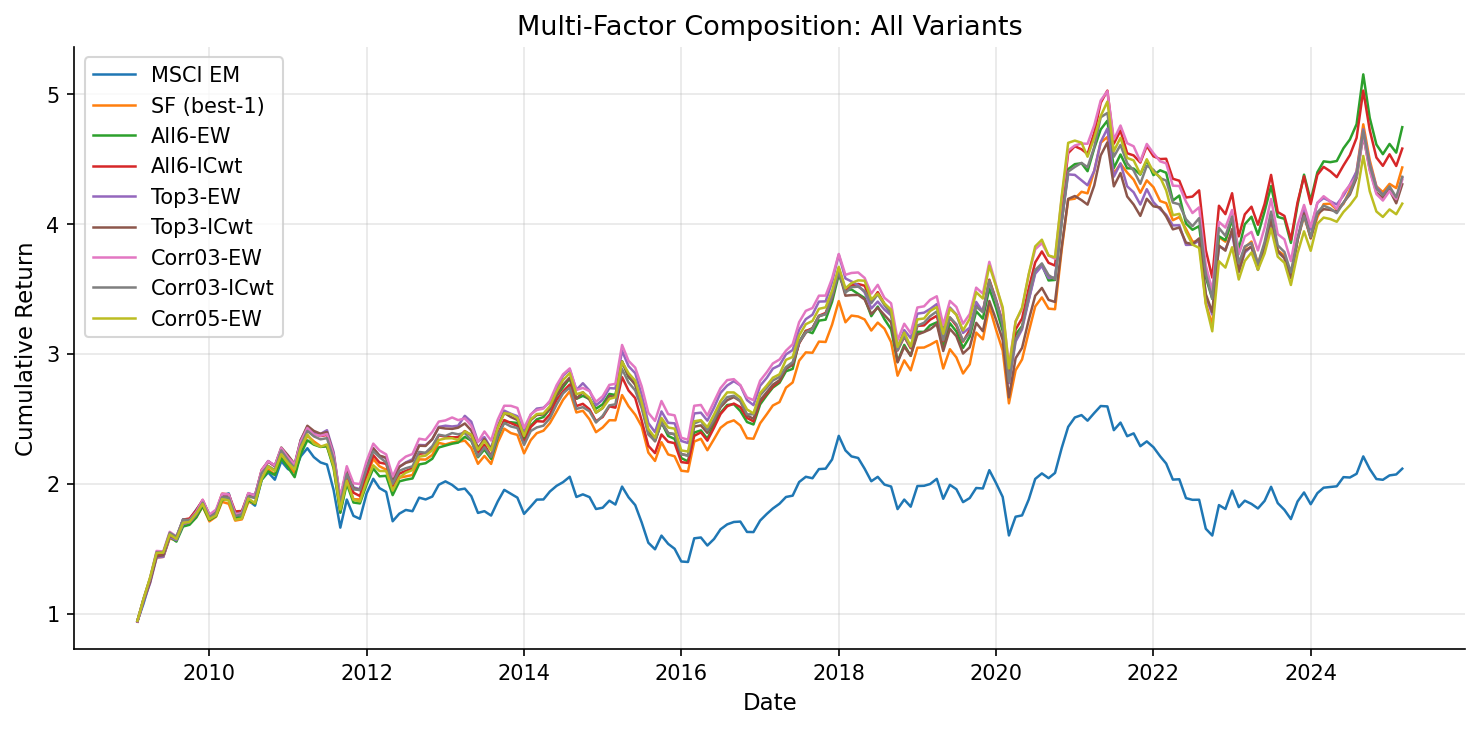

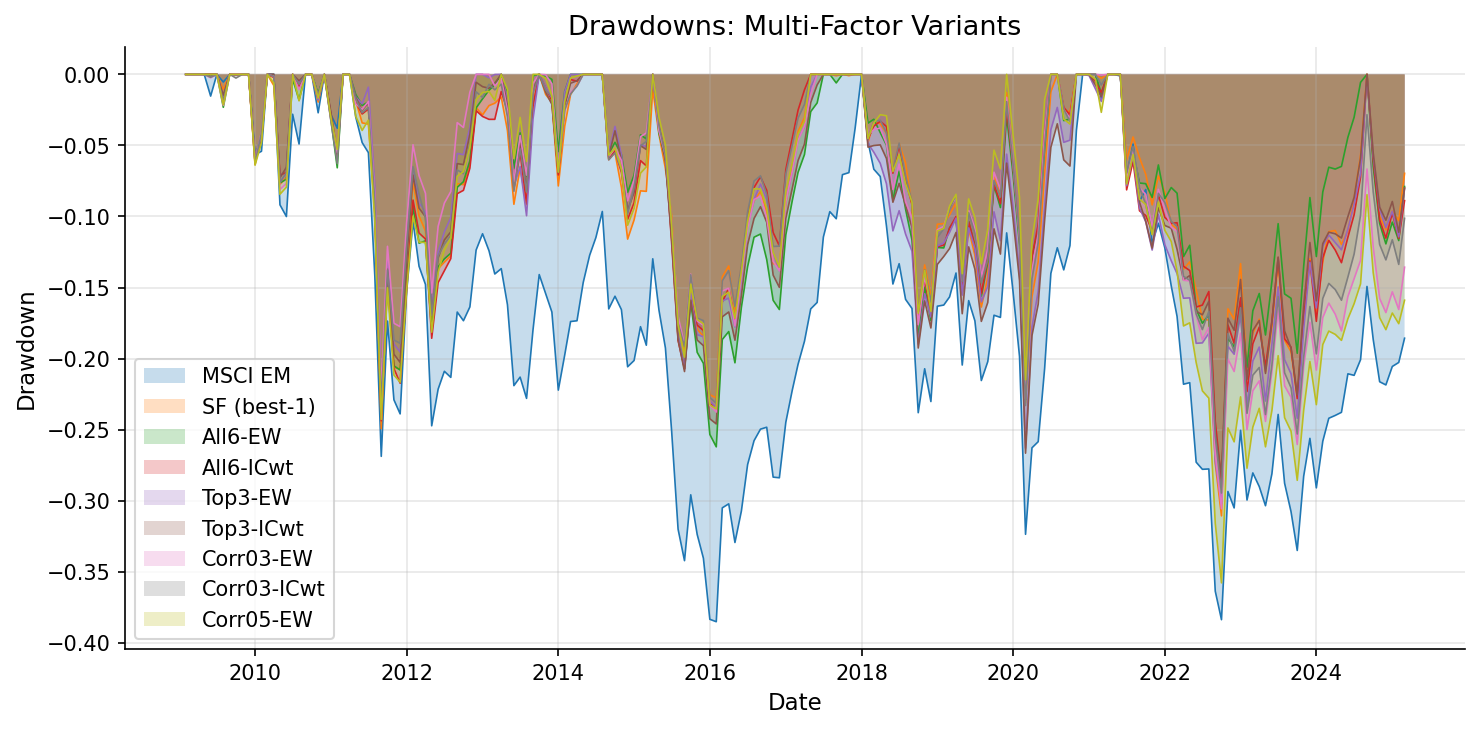

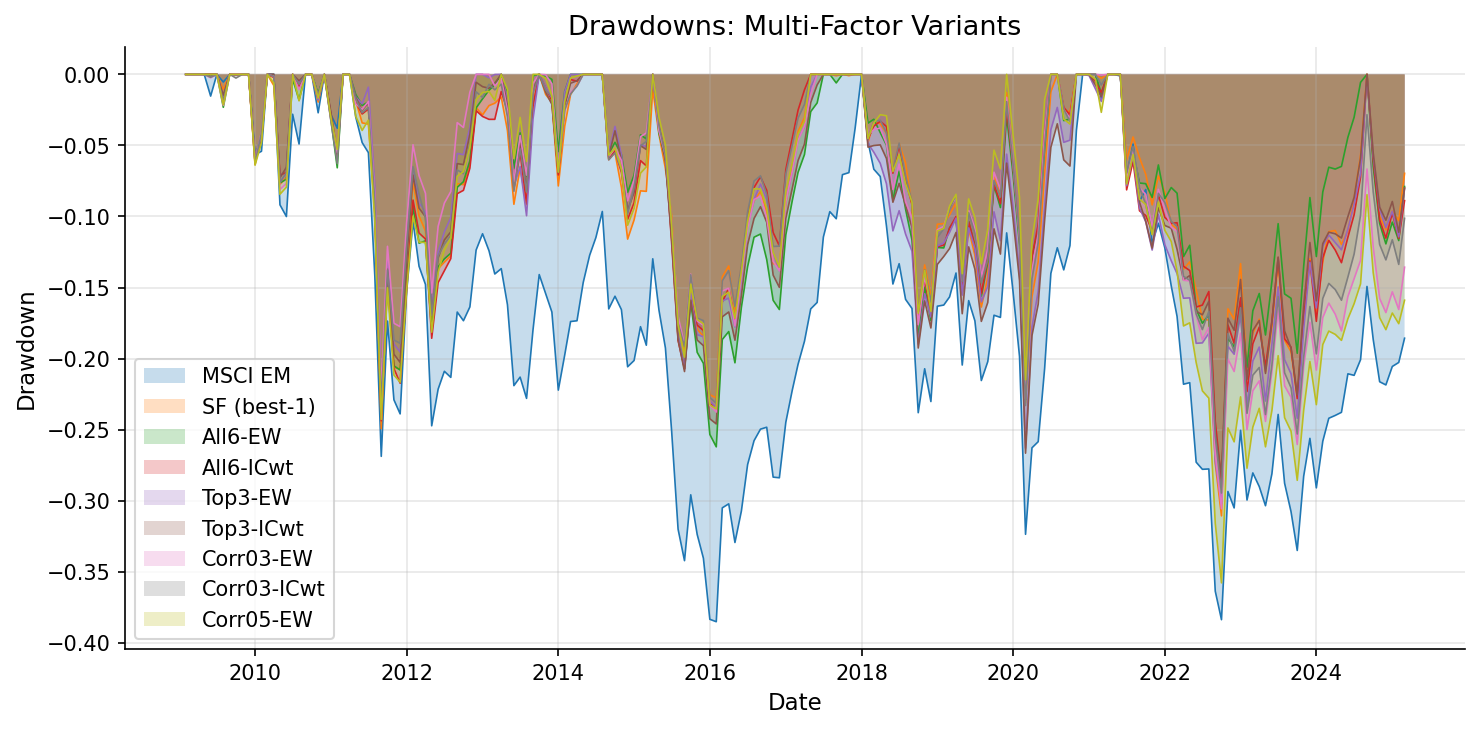

In [12]:
plot_cumulative_returns(
    perf_dict,
    title='Multi-Factor Composition: All Variants',
    save_path=f'{OUTPUT_DIR}/figures/exp3b_cumulative.pdf',
)

plot_drawdown(
    perf_dict,
    title='Drawdowns: Multi-Factor Variants',
    save_path=f'{OUTPUT_DIR}/figures/exp3b_drawdown.pdf',
)

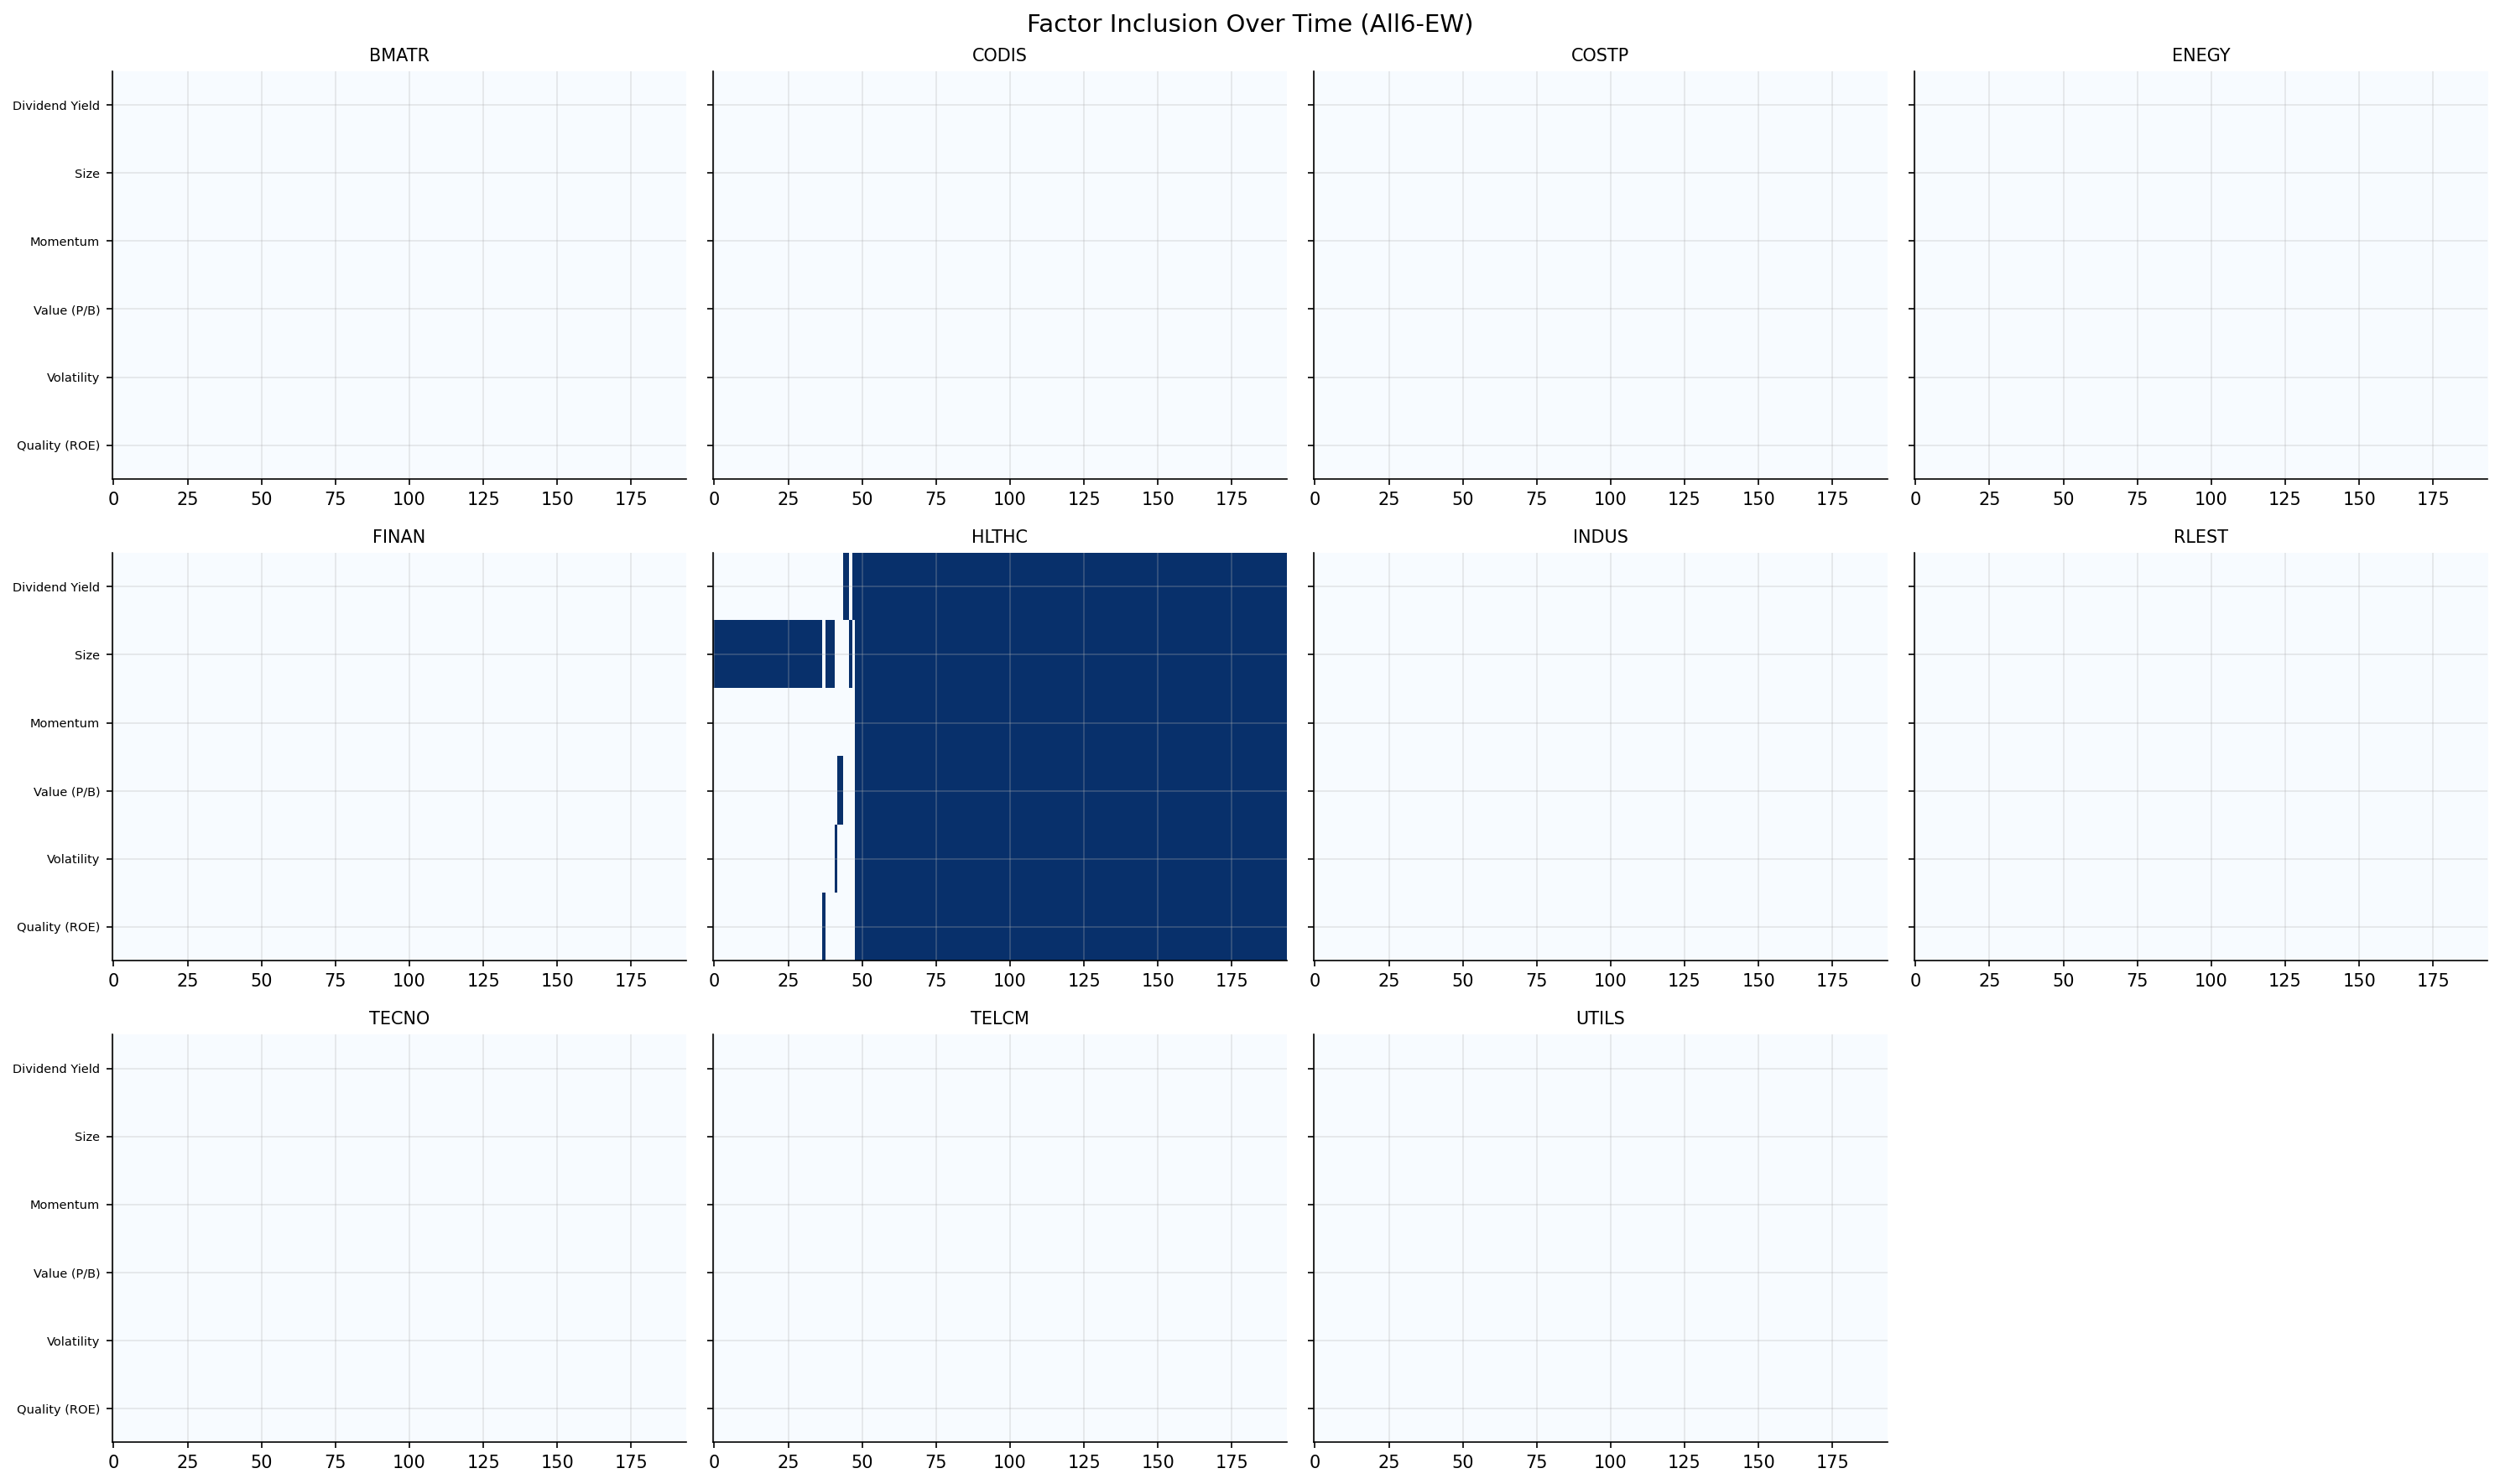

Saved: exp3b_factor_inclusion.pdf


In [13]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=True)
axes_flat = axes.flatten()

for idx, ind in enumerate(INDUSTRIES):
    ax = axes_flat[idx]
    det = best_details[ind]
    all_factors = sorted(set('|'.join(det['selected_factors']).split('|')))
    inclusion = pd.DataFrame(0, index=det['ym'], columns=all_factors)
    for _, row in det.iterrows():
        for f in row['selected_factors'].split('|'):
            inclusion.loc[row['ym'], f] = 1
    renamed = inclusion.rename(columns=factor_display)
    ax.imshow(renamed.T.values, aspect='auto', cmap='Blues', interpolation='nearest')
    ax.set_yticks(range(len(renamed.columns)))
    ax.set_yticklabels(renamed.columns, fontsize=7)
    ax.set_title(ind, fontsize=10)
    ax.set_xlabel('')

if len(INDUSTRIES) < len(axes_flat):
    axes_flat[-1].set_visible(False)

fig.suptitle(f'Factor Inclusion Over Time ({best_comp_label})', fontsize=14)
fig.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/figures/exp3b_factor_inclusion.pdf', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: exp3b_factor_inclusion.pdf')

## 9. Save Results

In [14]:
# Save all variant industry returns
for label in VARIANTS:
    safe = label.lower().replace('-', '_').replace('(', '').replace(')', '')
    variant_results[label]['wide'].to_csv(
        f'{OUTPUT_DIR}/csv/composite_{safe}_industry_returns.csv'
    )

# Save performance tables
perf.to_csv(f'{OUTPUT_DIR}/csv/exp3b_performance.csv')
is_oos.to_csv(f'{OUTPUT_DIR}/csv/exp3b_is_oos.csv')

# Save turnover summary
pd.Series(variant_turnovers, name='avg_monthly_turnover').to_csv(
    f'{OUTPUT_DIR}/csv/exp3b_turnovers.csv'
)

print('Saved all variant results.')
for label in VARIANTS:
    safe = label.lower().replace('-', '_').replace('(', '').replace(')', '')
    print(f'  composite_{safe}_industry_returns.csv')

Saved all variant results.
  composite_all6_ew_industry_returns.csv
  composite_all6_icwt_industry_returns.csv
  composite_top3_ew_industry_returns.csv
  composite_top3_icwt_industry_returns.csv
  composite_corr03_ew_industry_returns.csv
  composite_corr03_icwt_industry_returns.csv
  composite_corr05_ew_industry_returns.csv


## 10. Summary

Key findings from the multi-factor composition grid:

1. Eight stock-selection variants tested systematically across 11 industries.
2. Single-Factor (best-1 by rolling IC) compared against all-6-factor,
   top-3-factor, and IC-correlation-filtered composites.
3. Both equal-weight and IC-proportional weighting tested for each variant.
4. OOS Sharpe, turnover, and per-industry breakdown reported.
5. Best composite variant identified for downstream portfolio construction.